In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Combined Trend Strategy

## Hypothesis
We are testing a combination of 3 strategies.
1. Trend Following
2. Split Trend Following
3. Vol Reduction

### 1. Trend Following
We theorize the existence of trend / momentum premium, where we can obtain better risk-adjusted returns by going long the asset when recent returns are positive and going short the asset when recent returns are negative.

The momentum premium is well-documented in literature, even though the source of the premium is still being debated.

### 2. Split Trend Following
We note that the trend following strategy has a key parameter, which is the lookback period for which we calculate the recent returns. The optimal value of this parameter is dependent on market conditions. Attempting to optimize this parameter based on historical backtesting likely leads to over-fitting.

We propose to adjust our position based on multiple lookback periods as a weighted-sum of the signals suggested by each lookback period.

### 3. Vol Reduction
We propose to reduce the volatility of returns by reducing position during volatile periods. Using recent volatility and VIX-measures as a proxy for forward volatility, we can compute the forward variance and use it to adjust our position, reducing our exposure when forward volatility is high. This should help us to reduce our exposure during volatile economic periods and lead to better risk-adjusted returns.

## Import Libraries

In [32]:
import pandas as pd
import numpy as np
from utils.backtester import BackTester
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from utils.data_fetcher import YahooDataFetcher, TickerPriceDataFetcher
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import lightgbm as lgb
import optuna
from indicators.returns import calculate_binary_forward_returns, calculate_binary_returns, calculate_binary_MA_returns, calculate_forward_returns, calculate_returns, calculate_MA_returns
from indicators.breakout import calculate_breakout
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.volume import calculate_rel_volume
from indicators.trend import calculate_r2
import backtrader as bt
from strategies.base import BaseStrategy
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

## Utility Functions

In [33]:
def load_data(data):
    
    fetcher = TickerPriceDataFetcher()  
    asset_list = data['asset_list']
    ticker_list = asset_list + [data[ticker]['vol_measure'] for ticker in data['asset_list']]
    ticker_list.append('SHV')
    price_data = fetcher.load_data(ticker_list=ticker_list)
    
    for ticker in asset_list:
        vol_ticker = data[ticker]['vol_measure']
        df = price_data[ticker].copy()
        df_vol = price_data.get(vol_ticker)
        if df_vol is None:
            print(f'{vol_ticker} not found')
        else:
            df['vix'] = df_vol['close'].copy()
        data[ticker]['data'] = df.copy()

    ticker = 'SHV'
    data[ticker]['data'] = price_data[ticker].copy()
        
    return data




## Load Data

In [34]:
data = {
    'asset_list': ['SPY', 'TLT', 'GLD'],
    'SPY': {
        'vol_measure': '^VIX',
        'data': None,
    },
    'GLD': {
        'vol_measure': '^GVZ',
        'data': None,
    },
    'TLT': {
        'vol_measure': '^VXTLT',
        'data': None,
    },
    'SHV': {
        'data': None,
    },
    'current_date': None,
}


# Current date
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")
data['current_date'] = current_date


data = load_data(data)

INFO:utils.data_fetcher:Loading data for ['SPY', 'TLT', 'GLD', '^VIX', '^VXTLT', '^GVZ', 'SHV']
INFO:utils.data_fetcher:Fetching data for SPY with yfinance
ERROR:utils.data_fetcher:No existing file for SPY
INFO:utils.data_fetcher:Data for TLT already exists
INFO:utils.data_fetcher:Data for GLD already exists
INFO:utils.data_fetcher:Data for ^VIX already exists
INFO:utils.data_fetcher:Fetching data for ^VXTLT with yfinance
ERROR:yfinance:^VXTLT: Period 'max' is invalid, must be of the format 1d, 5d, etc.
INFO:utils.data_fetcher:Fetching data for ^VXTLT with yahoo_fin
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT with yahoo_fin
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT
INFO:utils.data_fetcher:Data for ^GVZ already exists
INFO:utils.data_fetcher:Data for SHV already exists


^VXTLT not found


## Parameters

In [41]:
lookforward_period = 21
lookback_periods = [21, 100, 200, 252]
rebalance_period = 21
capital = 64544
leverage = 10
atr_period = 14

In [36]:
import numpy as np
from scipy.stats import percentileofscore

class PercentileScaler:
    """
    Scales data to [0, 1] based on percentiles of the fitted data.
    
    Methods:
        fit(X): Compute percentiles for scaling.
        transform(X): Scale data based on fitted percentiles.
        fit_transform(X): Fit and transform in one step.
    """
    
    def __init__(self):
        self.reference_values = None
    
    def fit(self, X):
        """
        Compute reference percentiles from input array X.
        
        Args:
            X (array-like): Input data to compute percentiles from.
        """
        X = np.asarray(X)
        self.reference_values = np.sort(X.flatten())  # Store sorted values for percentile calculation
        return self
    
    def transform(self, X):
        """
        Scale input values to [0, 1] based on fitted percentiles.
        
        Args:
            X (array-like or scalar): Values to transform.
            
        Returns:
            Scaled values in [0, 1].
        """
        if self.reference_values is None:
            raise ValueError("Scaler has not been fitted yet. Call fit() first.")
        
        X = np.asarray(X)
        is_scalar = np.isscalar(X)
        X = np.array([X]) if is_scalar else X
        
        # Calculate percentile for each value
        scaled = np.array([percentileofscore(self.reference_values, x, kind='mean') / 100.0 
                          for x in X.flatten()])
        
        if is_scalar:
            return scaled[0]
        return scaled.reshape(X.shape)
    
    def fit_transform(self, X):
        """Fit and transform in one step."""
        return self.fit(X).transform(X)


# # Example usage

# # Create some test data
# data = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

# # Initialize and fit the scaler
# scaler = PercentileScaler()
# scaled_data = scaler.fit_transform(data)

# print("Original data:", data)
# print("Scaled data:", scaled_data)

# # Transform new single values
# print("\nSingle value transformations:")
# print("25 ->", scaler.transform(25))  # Should be ~0.2 (20th percentile)
# print("55 ->", scaler.transform(55))  # Should be ~0.5 (50th percentile)
# print("99 ->", scaler.transform(99))  # Should be ~0.9 (90th percentile)

# assert False

## Data Preprocessing

  0%|          | 0/3 [00:00<?, ?it/s]

SPY


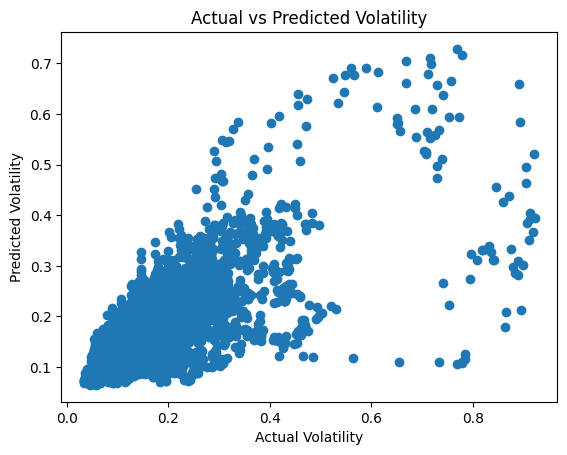

  0%|          | 0/8107 [00:00<?, ?it/s]

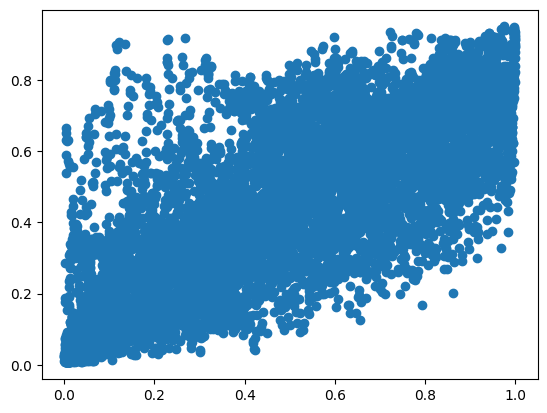

TLT


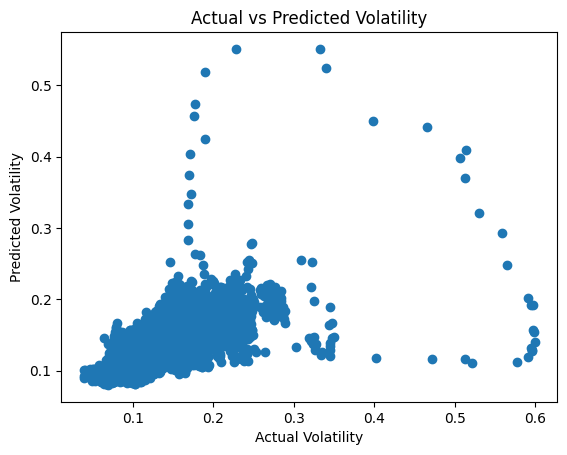

  0%|          | 0/5714 [00:00<?, ?it/s]

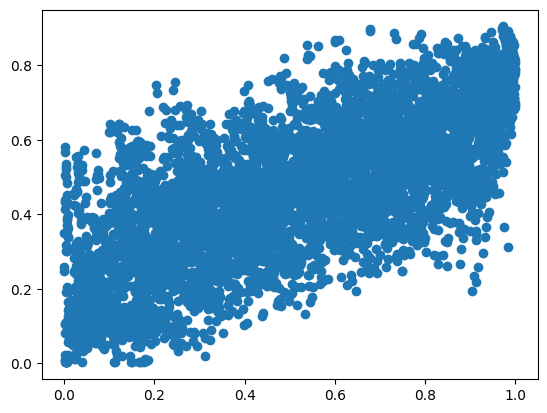

GLD


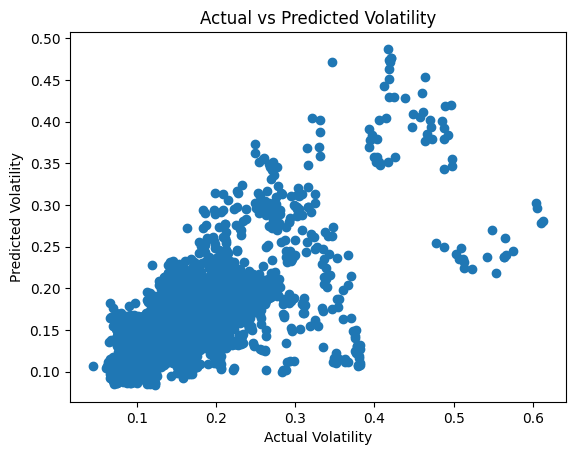

  0%|          | 0/5132 [00:00<?, ?it/s]

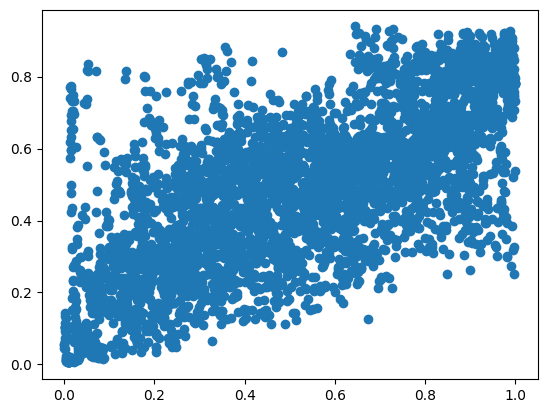

In [37]:
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()
    df_data['returns'] = df_data['close'].pct_change()
    df_data['vol_forward'] = calculate_forward_vol(df_data, lookforward_period)
    df_data['ret_forward'] = calculate_forward_returns(df_data, lookforward_period)
    df_data['ATR'] = calculate_atr(df_data, 14)
    annualized_vol = df_data['returns'].std() * np.sqrt(252)
    annualized_var = annualized_vol ** 2
    data[ticker]['annualized_var'] = annualized_var
    data[ticker]['annualized_vol'] = annualized_vol
    
    ##############################################################
    # Variance Scale
    ##############################################################
    df_data['var_forward'] = df_data['vol_forward'] ** 2

    # Percentile Scaling
    p_scaler = PercentileScaler()
    p_scaler.fit(df_data['var_forward'].dropna().values.reshape(-1, 1))
    var_scaled = p_scaler.transform(df_data['var_forward'].values.reshape(-1, 1))
    df_data['vol_scaling_percentile'] = 1 - var_scaled
    data[ticker]['var_scaler_percentile'] = p_scaler

    # Min-Max Scaling
    mm_scaler = MinMaxScaler(feature_range=(0, 1))
    df_data['vol_scaling_minmax'] = 1 - mm_scaler.fit_transform(df_data['var_forward'].values.reshape(-1, 1))
    data[ticker]['var_scaler_minmax'] = mm_scaler


    ##############################################################
    # Volatility Forecast
    ##############################################################
    # Use Linear Regression to forecast volatility from ATR and VIX
    df_train = df_data.dropna().copy()
    y = df_train['vol_forward'].to_numpy()
    X = []
    input_cols = []
    if 'vix' in df_train.columns:
        X.append(df_train['vix'].to_numpy().reshape(-1, 1))
        input_cols.append('vix')
    if 'ATR' in df_train.columns:
        X.append(df_train['ATR'].to_numpy().reshape(-1, 1))
        input_cols.append('ATR')
    X = np.concatenate(X, axis=1)       
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    plt.scatter(y, y_pred)
    plt.xlabel('Actual Volatility')
    plt.ylabel('Predicted Volatility')
    plt.title('Actual vs Predicted Volatility')
    plt.show()
    data[ticker]['vol_model'] = model

    for i, r in tqdm(df_data.iterrows(), total=df_data.shape[0]):
        if 'vix' in input_cols and np.isnan(r['vix']):
            df_data.loc[i, 'vol_forward_pred'] = np.nan
            continue
        if 'ATR' in input_cols and np.isnan(r['ATR']):
            df_data.loc[i, 'vol_forward_pred'] = np.nan
            continue
        
        df_data.loc[i, 'vol_forward_pred'] = model.predict([[r[f] for f in input_cols]])
    df_data['var_forward_pred'] = df_data['vol_forward_pred'] ** 2
    df_data['vol_scaling_percentile_pred'] = 1 - p_scaler.transform(df_data['var_forward_pred'].values.reshape(-1, 1))
    df_data['vol_scaling_minmax_pred'] = 1 - mm_scaler.transform(df_data['var_forward_pred'].values.reshape(-1, 1))
    
    plt.scatter(df_data['vol_scaling_percentile'], df_data['vol_scaling_percentile_pred'])
    plt.show()

    ##############################################################
    # Save
    ##############################################################
    data[ticker]['data'] = df_data

### Multi-Asset Trend Vol

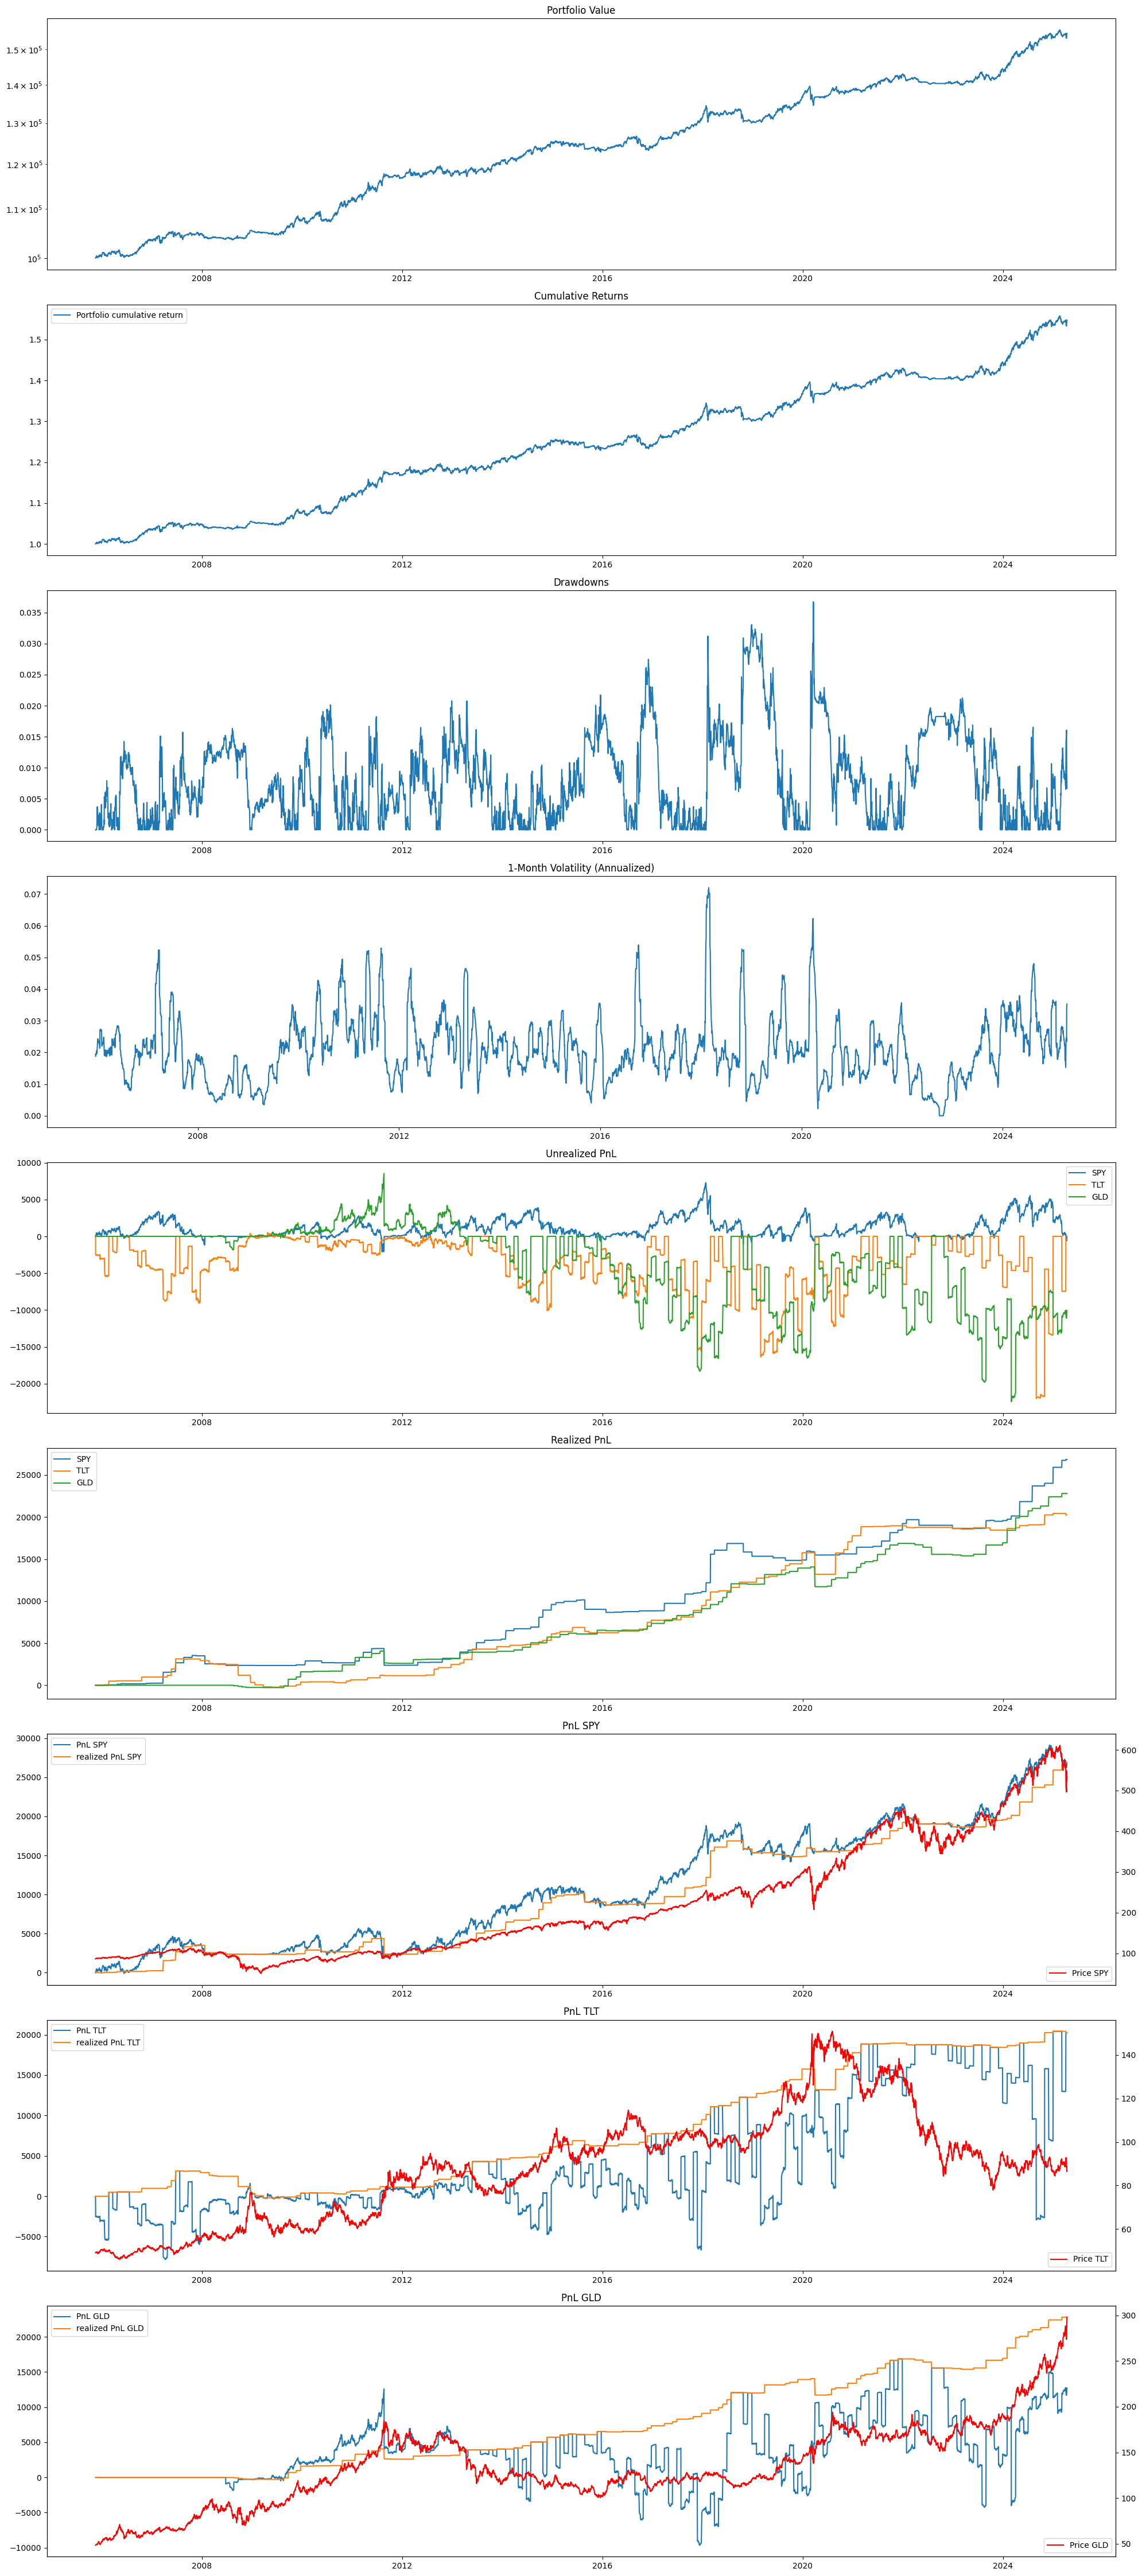

cagr: 0.02
volatility: 0.02
sharpe: 0.98
max_drawdown: 0.04
cumulative_returns: 0.55


In [38]:
class MultiAssetTrendVol(BaseStrategy):

    params = (
        ('lookback_periods', [21, 100, 252]),
        ('rebalance_period', 21),
        ('dfs_vol', dict()),
        ('vol_scaling_col', 'vol_scaling_percentile'),
        ('asset_weights', dict()),
        ('lookback_weights', dict()),
    )

    def __init__(self):
        super().__init__()
        # Recent returns to calculate trend
        self.returns = dict()
        for ticker in self.p.tickers:
            data = self.getdatabyname(ticker)
            self.returns[ticker] = dict()
            for period in self.p.lookback_periods:
                self.returns[ticker][period] = bt.indicators.PercentChange(data.close, period=period)
        # Weights for each lookback period
        # self.weight = 1 / len(self.p.lookback_periods)
        self.lookback_weights = self.p.lookback_weights
        if len(self.lookback_weights) == 0:
            self.lookback_weights = {f: 1 / len(self.p.lookback_periods) for f in self.p.lookback_periods}
        sum_weights = sum(self.lookback_weights.values())
        for f in self.lookback_weights:
            self.lookback_weights[f] /= sum_weights
        # Track rebalance interval
        self.rebalance_day = 0
        # Vol scaling
        self.dfs_vol = self.p.dfs_vol
        for ticker in self.p.tickers:
            df_vol = self.dfs_vol[ticker]
            if self.p.vol_scaling_col not in df_vol.columns:
                raise ValueError(f"df_vol must have column {self.p.vol_scaling_col}")
        # Asset allocation weights
        sum_weights = sum(self.p.asset_weights.values())
        for ticker in self.p.asset_weights:
            self.p.asset_weights[ticker] /= sum_weights
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_capital = self.broker.getvalue()
            current_date = self.datetime.date()
            for ticker in self.p.tickers:
                data = self.getdatabyname(ticker)
                current_position = self.broker.getposition(data).size
                ticker_capital = current_capital * self.p.asset_weights[ticker]
                # Trend value
                trend_value = 0.0
                for period in self.p.lookback_periods:
                    if self.returns[ticker][period][0] > 0:
                        trend_value += self.lookback_weights[period]
                # Vol scaling
                df_vol = self.dfs_vol[ticker]
                vol_scaling = df_vol.loc[df_vol.index == pd.to_datetime(current_date), self.p.vol_scaling_col].values[0]
                vol_scaling = np.clip(vol_scaling, 0, 1)
                # Calculate target position
                target_position = trend_value * vol_scaling * ticker_capital / self.data.close[0]
                # target_position = int(target_position)
                # Submit order
                self._submit_order(ticker, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1
    
btr = BackTester({ticker: data[ticker]['data'] for ticker in data['asset_list']})
btr.add_strategy(
    MultiAssetTrendVol, 
    tickers=data['asset_list'], 
    price_data={ticker: data[ticker]['data'] for ticker in data['asset_list']}, 
    rebalance_period=rebalance_period, 
    dfs_vol={ticker: data[ticker]['data'] for ticker in data['asset_list']}, 
    lookback_periods=lookback_periods,
    asset_weights={'SPY': 0.33, 'TLT': 0.33, 'GLD': 0.33},
    vol_scaling_col='vol_scaling_percentile_pred',
    # vol_scaling_col='vol_scaling_percentile',
    # vol_scaling_col='vol_scaling_minmax_pred',
    # lookback_weights={21: 21, 100: 100, 252: 252},
)
results = btr.backtest()
btr.plot_results()
for key in results:
    if key == 'returns': continue
    print(f"{key}: {results[key]:.2f}")

## Trade strategy

In [42]:
leveraged_capital = leverage * capital
consumed_capital = 0
for ticker in data['asset_list']:

    df = data[ticker]['data'].copy()
    print('-----------------------------------')
    print(f'ticker: {ticker}, date: {df.index[-1]}')
    
    # trend value
    lookback_weight = {f: 1/len(lookback_periods) for f in lookback_periods}
    trend_value = 0
    ret_list = []
    for period in lookback_periods:
        df[f'ret_{period}'] = calculate_returns(df, period)
        ret = df[f'ret_{period}'].to_list()[-1]
        ret_list.append((period, 0 if ret < 0 else 1))
        if ret > 0:
            trend_value += lookback_weight[period]
    
    # vol scaling
    vol_scaling = df['vol_scaling_percentile_pred'].to_list()[-1]
    vol_scaling = np.clip(vol_scaling, 0, 1)
    
    # asset allocation
    asset_weight = 1 / len(data['asset_list'])
    
    # target position
    target_sizing = trend_value * vol_scaling * asset_weight
    target_position =  target_sizing * leveraged_capital
    consumed_capital += target_position

    # num shares
    num_shares = int((target_sizing * leveraged_capital) / df['close'].to_list()[-1])

    print(f'trend_value: {trend_value:.2f} from {ret_list}')
    print(f'vol_scaling: {vol_scaling:.2f}')
    print(f'asset_weight: {asset_weight:.2f}')
    print(f"target_position: {target_sizing:.2f} -> {target_position:.2f}")
    print(f'num_shares: {num_shares}')

df = data['SHV']['data'].copy()
num_shares = int((capital - consumed_capital) / df['close'].to_list()[-1])
num_shares = max(num_shares, 0)
print('-----------------------------------')
print(f'ticker: SHV, date: {df.index[-1]}')
print(f'num_shares: {num_shares}')

-----------------------------------
ticker: SPY, date: 2025-04-11 00:00:00
trend_value: 0.25 from [(21, 0), (100, 0), (200, 0), (252, 1)]
vol_scaling: 0.02
asset_weight: 0.33
target_position: 0.00 -> 1290.45
num_shares: 2
-----------------------------------
ticker: TLT, date: 2025-04-11 00:00:00
trend_value: 0.00 from [(21, 0), (100, 0), (200, 0), (252, 0)]
vol_scaling: 0.05
asset_weight: 0.33
target_position: 0.00 -> 0.00
num_shares: 0
-----------------------------------
ticker: GLD, date: 2025-04-11 00:00:00
trend_value: 1.00 from [(21, 1), (100, 1), (200, 1), (252, 1)]
vol_scaling: 0.13
asset_weight: 0.33
target_position: 0.04 -> 28666.58
num_shares: 96
-----------------------------------
ticker: SHV, date: 2025-04-11 00:00:00
num_shares: 313


# END